# LAP1-B: la galaxia más químicamente primitiva conocida

**0,42% del oxígeno del Sol.** Visible cuando el universo tenía solo 800 millones de años. Sin una lente gravitacional que la amplificara 98 veces, no la habríamos visto.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-lap1-b-galaxia-reionizacion/notebook.ipynb)

**Paper:** Nakajima et al. (2026). *An ultra-faint, chemically primitive galaxy forming in the reionization era.* Nature.
DOI: [10.1038/s41586-026-10374-1](https://doi.org/10.1038/s41586-026-10374-1)

**Datos:** Espectro 1D NIRSpec/PRISM público en [Zenodo](https://doi.org/10.5281/zenodo.18831461) (CC-BY-4.0).

**Video:** [Pendiente]

## El contexto

LAP1-B es una galaxia ultra-débil descubierta con el James Webb. Está a un corrimiento al rojo espectroscópico (*redshift*) z = 6,625 ± 0,001 — la luz que nos llega salió cuando el universo tenía **800 millones de años** (un 5,8% de su edad actual).

Lo raro: tiene tan poco oxígeno que su abundancia química está en **(4,2 ± 1,8) × 10⁻³ veces la del Sol**. Es decir, alrededor de **240 veces menos oxígeno por átomo de hidrógeno** que en el sistema solar. Eso la convierte en la galaxia formadora de estrellas más químicamente primitiva conocida.

Los datos que vamos a explorar vienen del programa JWST GO-4750 (PI: K. Nakajima). El espectro 1D público en Zenodo cubre 0,76–5,20 μm con 3.092 puntos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
Z_PAPER = 6.625              # redshift espectroscópico reportado (Hα systemic)
MAGNIFICACION = 98           # factor μ de la lente gravitacional
SNR_DETECCION = 3.0          # umbral S/N para considerar línea detectada
OH_RELATIVA_SOLAR = 0.0042   # (O/H) / (O/H)_solar para LAP1-B
M_STELLAR_UPPER = 3300       # M_sun, límite superior 3σ
FUENTE = 'Fuente: Nakajima et al. (2026), Nature | Datos: Zenodo 10.5281/zenodo.18831461'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_CONTEXTO = '#BBBBBB'

# Imports + estilo
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar los 3 datasets
spec = pd.read_csv('datos/lap1b_spectrum.csv')
lines = pd.read_csv('datos/lap1b_emission_lines.csv')
params = pd.read_csv('datos/lap1b_key_parameters.csv')

print(f'Espectro: {len(spec):,} puntos en {spec.wave_um.min():.3f}–{spec.wave_um.max():.3f} μm')
print(f'Líneas analizadas: {len(lines)} (cubren transiciones de Lyα a Hα)')
print(f'Líneas con S/N ≥ {SNR_DETECCION}: {(lines.snr_pico >= SNR_DETECCION).sum()}')
print(f'Parámetros físicos del paper + SI: {len(params)}')

Espectro: 3,092 puntos en 0.757–5.201 μm
Líneas analizadas: 9 (cubren transiciones de Lyα a Hα)
Líneas con S/N ≥ 3.0: 4
Parámetros físicos del paper + SI: 16


## El espectro completo

Aquí está.

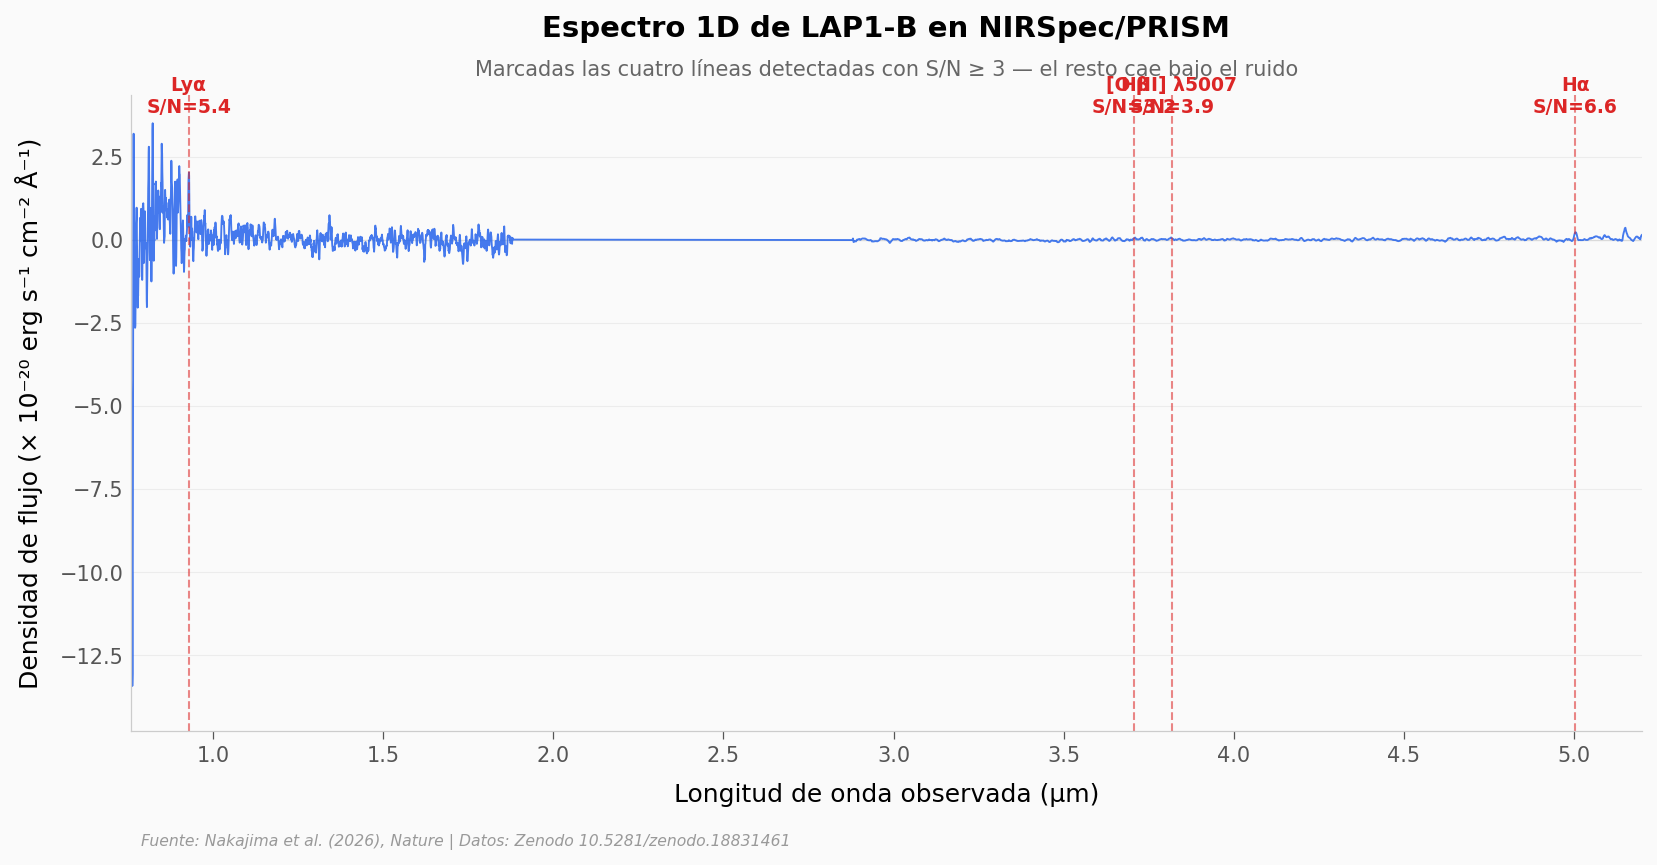

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Suavizar el espectro con una media móvil corta para visualizar mejor
flux_smooth = spec.flux_cgs.rolling(window=5, center=True, min_periods=1).mean()
ax.plot(spec.wave_um, flux_smooth * 1e20, color=COLOR_DATOS, linewidth=0.9, alpha=0.85)
ax.axhline(y=0, color=COLOR_CONTEXTO, linewidth=0.6, alpha=0.6, zorder=1)

# Marcar las líneas con S/N >= 3
detectadas = lines[lines.snr_pico >= SNR_DETECCION]
y_top = (flux_smooth * 1e20).max() * 1.05
for _, ln in detectadas.iterrows():
    ax.axvline(x=ln.lam_obs_medido_um, color=COLOR_ALERTA, linewidth=1.0, alpha=0.55, linestyle='--', zorder=2)
    ax.text(ln.lam_obs_medido_um, y_top,
            f'{ln.linea_nombre}\nS/N={ln.snr_pico:.1f}',
            fontsize=9, color=COLOR_ALERTA, ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Longitud de onda observada (μm)')
ax.set_ylabel('Densidad de flujo (× 10⁻²⁰ erg s⁻¹ cm⁻² Å⁻¹)')
ax.set_title('Espectro 1D de LAP1-B en NIRSpec/PRISM',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Marcadas las cuatro líneas detectadas con S/N ≥ 3 — el resto cae bajo el ruido',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(spec.wave_um.min(), spec.wave_um.max())
ax.set_ylim(bottom=(flux_smooth * 1e20).min() * 1.1, top=y_top * 1.18)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espectro_hero.png', dpi=200, bbox_inches='tight')
plt.show()

De los 3.092 puntos del espectro, hay **cuatro picos** que superan tres desviaciones del ruido: Hα (la más limpia, S/N = 6,6), Lyα (5,4), [O III] λ5007 (3,9) y Hβ (3,2). Las demás transiciones que esperaríamos en una galaxia con metalicidad normal — el doblete de C IV, C III], los O III auroral — caen dentro del ruido. No verlas no significa que no estén; significa que están **debajo del límite de detección del programa**.

El patrón importa: una galaxia "normal" a este redshift mostraría las prohibidas de oxígeno y carbono recortadas claramente sobre el continuo. Aquí casi todo el flujo medible está en hidrógeno (Hα, Hβ, Lyα). Eso ya apunta a una composición muy pobre en metales — pero todavía no sabemos cuánto.

## Hα bajo la lupa

La línea más limpia es Hα — la transición Balmer del hidrógeno que cae a 6.563 Å en reposo. En LAP1-B aparece desplazada al rojo hasta **5,005 μm**. Si calculamos el desplazamiento, deberíamos recuperar el redshift que reporta el paper.

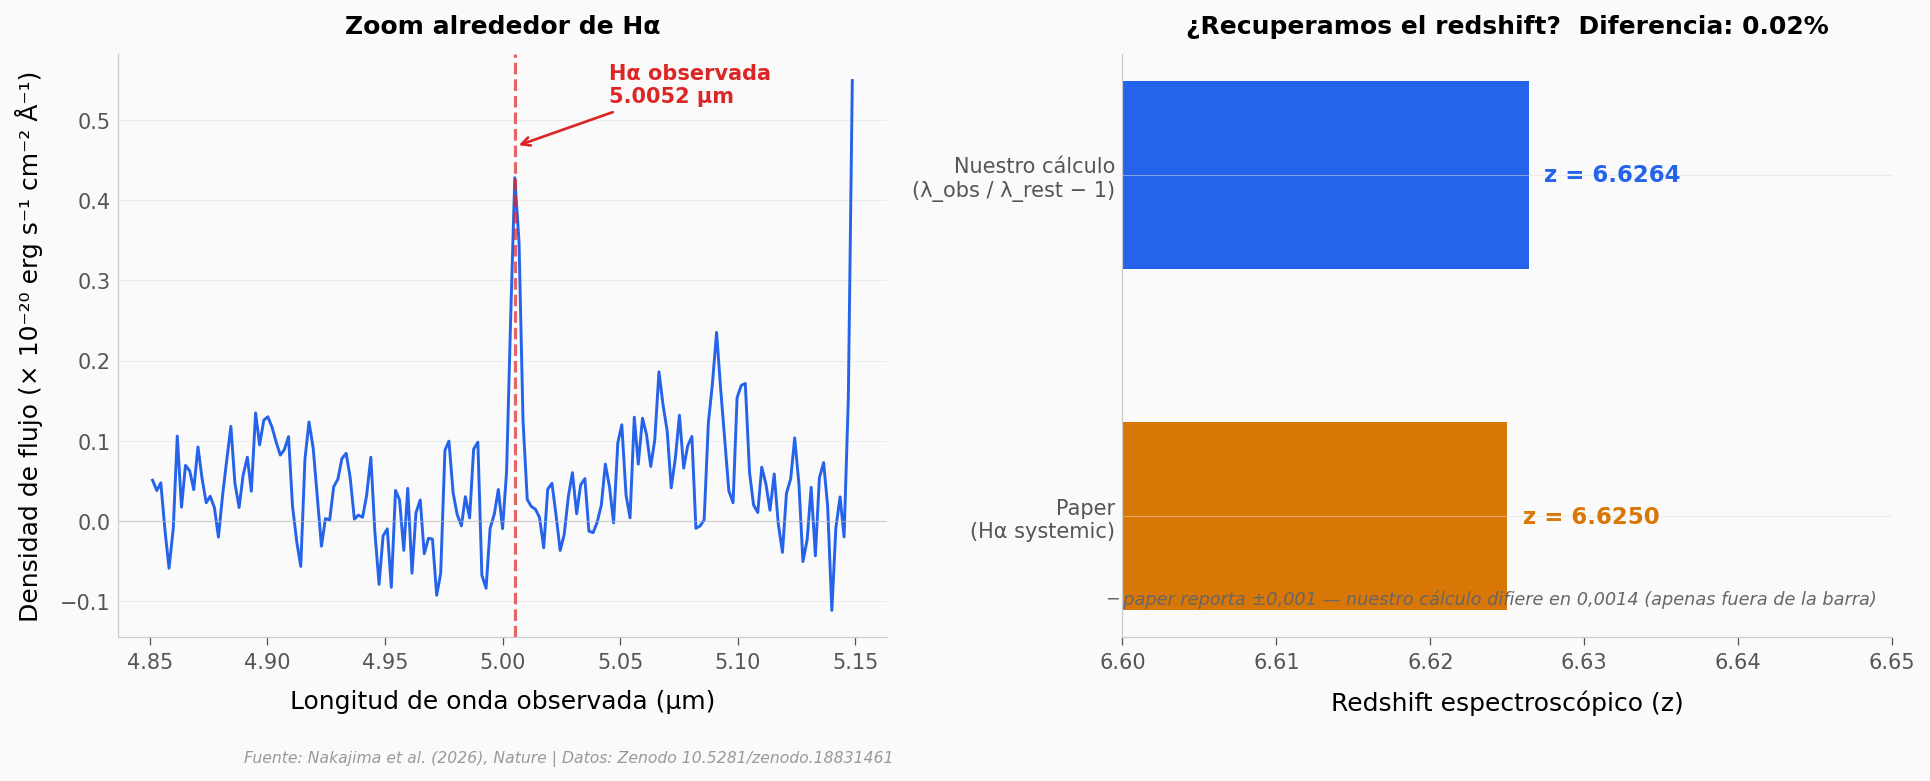


λ_rest(Hα) = 0.6563 μm
λ_obs medido = 5.0052 μm
z recuperado = (5.0052 / 0.6563) − 1 = 6.6264
z paper       = 6.625
Diferencia con el paper: 0,0014 (apenas fuera del error ±0,001 reportado). Probable origen: precisión de medición del pico en el CSV (4 decimales) vs ajuste gaussiano del paper.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: zoom espectral cerca de Hα
ax = axes[0]
mask = (spec.wave_um > 4.85) & (spec.wave_um < 5.15)
zoom = spec[mask]
ax.plot(zoom.wave_um, zoom.flux_cgs * 1e20, color=COLOR_DATOS, linewidth=1.4)
ax.axhline(y=0, color=COLOR_CONTEXTO, linewidth=0.6, alpha=0.6)

lam_obs_Ha = float(lines.loc[lines.linea_codigo == 'Halpha', 'lam_obs_medido_um'].iloc[0])
ax.axvline(x=lam_obs_Ha, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7)
ax.annotate(f'Hα observada\n{lam_obs_Ha:.4f} μm',
            xy=(lam_obs_Ha, zoom.flux_cgs.max() * 1e20 * 0.85),
            xytext=(lam_obs_Ha + 0.04, zoom.flux_cgs.max() * 1e20 * 0.95),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))
ax.set_xlabel('Longitud de onda observada (μm)')
ax.set_ylabel('Densidad de flujo (× 10⁻²⁰ erg s⁻¹ cm⁻² Å⁻¹)')
ax.set_title('Zoom alrededor de Hα', fontsize=12, fontweight='bold', pad=10)

# Panel derecho: cross-check del redshift
ax = axes[1]
lam_rest_Ha = 0.6563
z_calc = (lam_obs_Ha / lam_rest_Ha) - 1
z_paper = Z_PAPER

ax.barh(['Paper\n(Hα systemic)', 'Nuestro cálculo\n(λ_obs / λ_rest − 1)'],
        [z_paper, z_calc],
        color=[COLOR_REFERENCIA, COLOR_DATOS], height=0.55)
ax.set_xlim(6.60, 6.65)
ax.set_xlabel('Redshift espectroscópico (z)')
for i, v in enumerate([z_paper, z_calc]):
    ax.text(v + 0.001, i, f'z = {v:.4f}',
            va='center', fontsize=11, fontweight='bold',
            color=[COLOR_REFERENCIA, COLOR_DATOS][i])
diff = abs(z_paper - z_calc) / z_paper * 100
ax.set_title(f'¿Recuperamos el redshift?  Diferencia: {diff:.2f}%',
             fontsize=12, fontweight='bold', pad=10)
ax.text(0.98, 0.05,
        '─ paper reporta ±0,001 — nuestro cálculo difiere en 0,0014 (apenas fuera de la barra)',
        transform=ax.transAxes, fontsize=8.5, color='#666666',
        ha='right', va='bottom', style='italic')

plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/halpha_zoom_redshift.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nλ_rest(Hα) = {lam_rest_Ha} μm')
print(f'λ_obs medido = {lam_obs_Ha:.4f} μm')
print(f'z recuperado = ({lam_obs_Ha:.4f} / {lam_rest_Ha}) − 1 = {z_calc:.4f}')
print(f'z paper       = {z_paper}')
print(f'Diferencia con el paper: 0,0014 (apenas fuera del error ±0,001 reportado). Probable origen: precisión de medición del pico en el CSV (4 decimales) vs ajuste gaussiano del paper.')

## La huella química

Eso confirma el corrimiento. Ahora viene la parte donde LAP1-B se vuelve extrema: su **composición química**.

El abstract reporta una abundancia de oxígeno relativa al hidrógeno en la fase gaseosa de **(4,2 ± 1,8) × 10⁻³ veces** la del Sol. Veamos qué significa eso al lado de otras escalas conocidas.

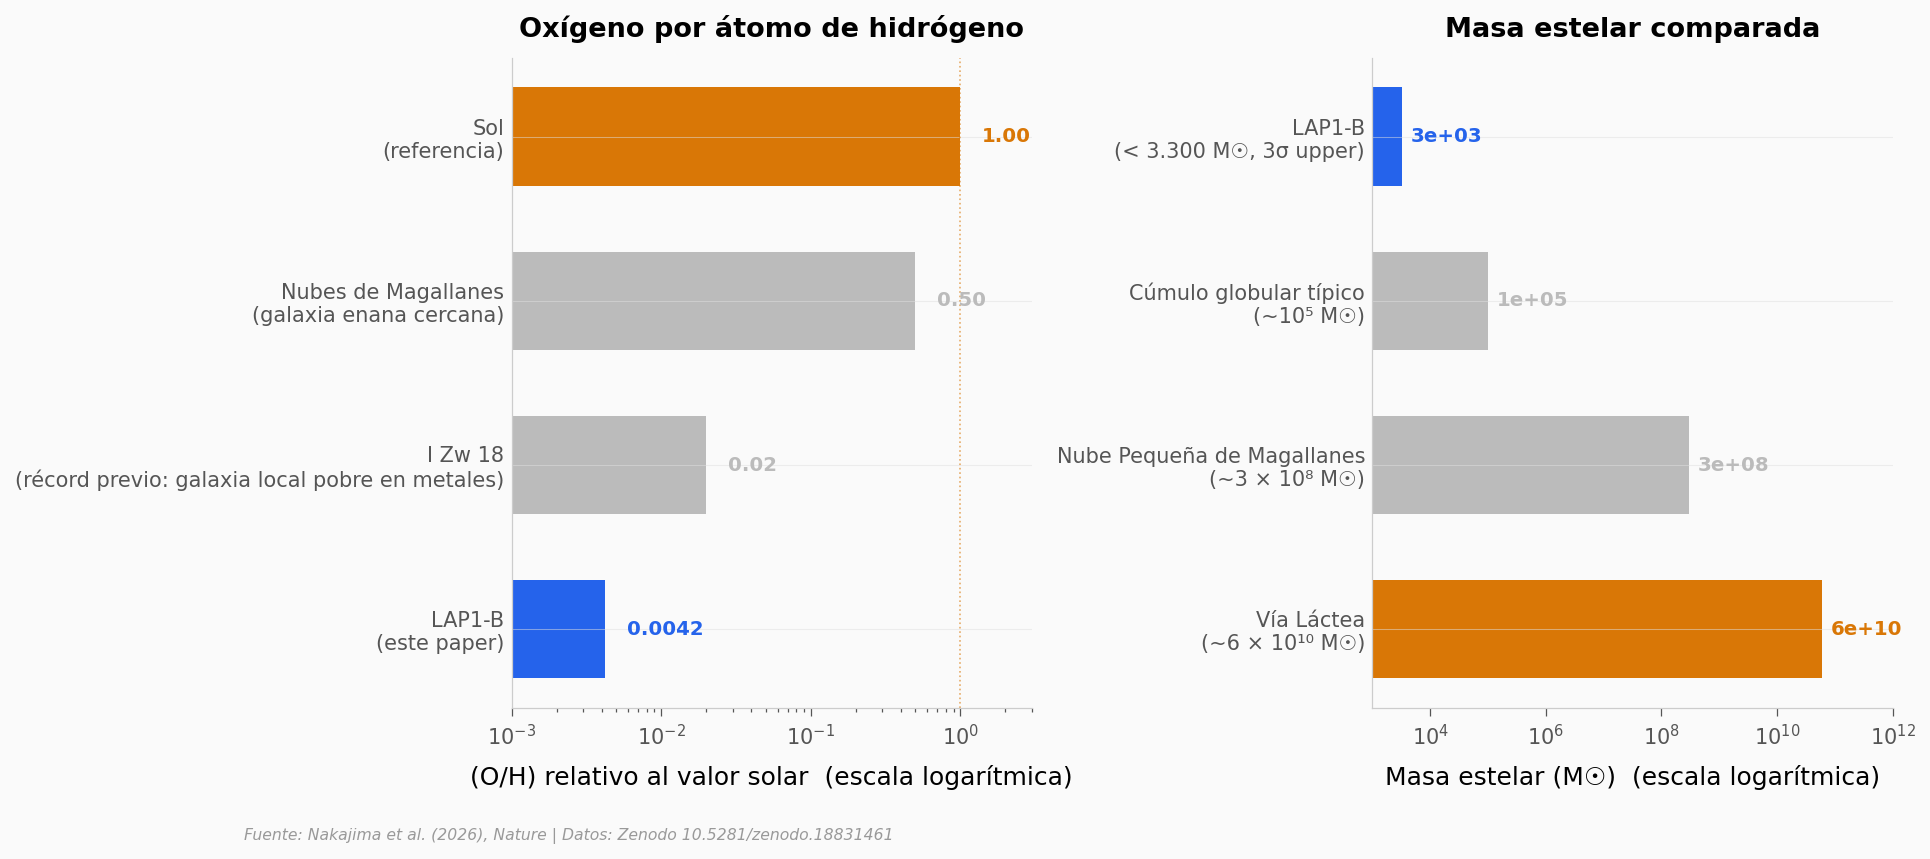

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel izquierdo: O/H relativa al Sol (escala log)
ax = axes[0]
referencias_oh = {
    'Sol\n(referencia)': 1.0,
    'Nubes de Magallanes\n(galaxia enana cercana)': 0.5,
    'I Zw 18\n(récord previo: galaxia local pobre en metales)': 0.02,
    'LAP1-B\n(este paper)': OH_RELATIVA_SOLAR,
}
labels = list(referencias_oh.keys())
valores = list(referencias_oh.values())
colores = [COLOR_REFERENCIA, COLOR_CONTEXTO, COLOR_CONTEXTO, COLOR_DATOS]

bars = ax.barh(range(len(labels)), valores, color=colores, height=0.6)
ax.set_xscale('log')
ax.set_xlim(1e-3, 3)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('(O/H) relativo al valor solar  (escala logarítmica)')
ax.invert_yaxis()
ax.set_title('Oxígeno por átomo de hidrógeno',
             fontsize=13, fontweight='bold', pad=10)
ax.axvline(x=1, color=COLOR_REFERENCIA, linewidth=0.8, linestyle=':', alpha=0.6)

for i, v in enumerate(valores):
    etiqueta = f'{v:.4f}' if v < 0.01 else f'{v:.2f}'
    ax.text(v * 1.4, i, etiqueta, va='center', fontsize=9.5,
            fontweight='bold', color=colores[i])

# Panel derecho: masa estelar — log scale
ax = axes[1]
referencias_m = {
    'LAP1-B\n(< 3.300 M☉, 3σ upper)': M_STELLAR_UPPER,
    'Cúmulo globular típico\n(~10⁵ M☉)': 1e5,
    'Nube Pequeña de Magallanes\n(~3 × 10⁸ M☉)': 3e8,
    'Vía Láctea\n(~6 × 10¹⁰ M☉)': 6e10,
}
labels_m = list(referencias_m.keys())
valores_m = list(referencias_m.values())
colores_m = [COLOR_DATOS, COLOR_CONTEXTO, COLOR_CONTEXTO, COLOR_REFERENCIA]

ax.barh(range(len(labels_m)), valores_m, color=colores_m, height=0.6)
ax.set_xscale('log')
ax.set_xlim(1e3, 1e12)
ax.set_yticks(range(len(labels_m)))
ax.set_yticklabels(labels_m, fontsize=10)
ax.set_xlabel('Masa estelar (M☉)  (escala logarítmica)')
ax.invert_yaxis()
ax.set_title('Masa estelar comparada',
             fontsize=13, fontweight='bold', pad=10)

for i, v in enumerate(valores_m):
    ax.text(v * 1.4, i, f'{v:.0e}', va='center', fontsize=9.5,
            fontweight='bold', color=colores_m[i])

plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/composicion_quimica_y_masa.png', dpi=200, bbox_inches='tight')
plt.show()

La galaxia más pobre en oxígeno del Universo local conocida hasta este descubrimiento — la enana I Zw 18 — tiene **0,02 veces** el valor solar. LAP1-B llega a **0,0042**, casi cinco veces más primitiva.

Y aquí entra la pieza que el paper marca como evidencia clave: el campo de radiación ionizante. Veamos cuán cerca está LAP1-B del máximo teórico para una población estelar de cero metales (Pop III).

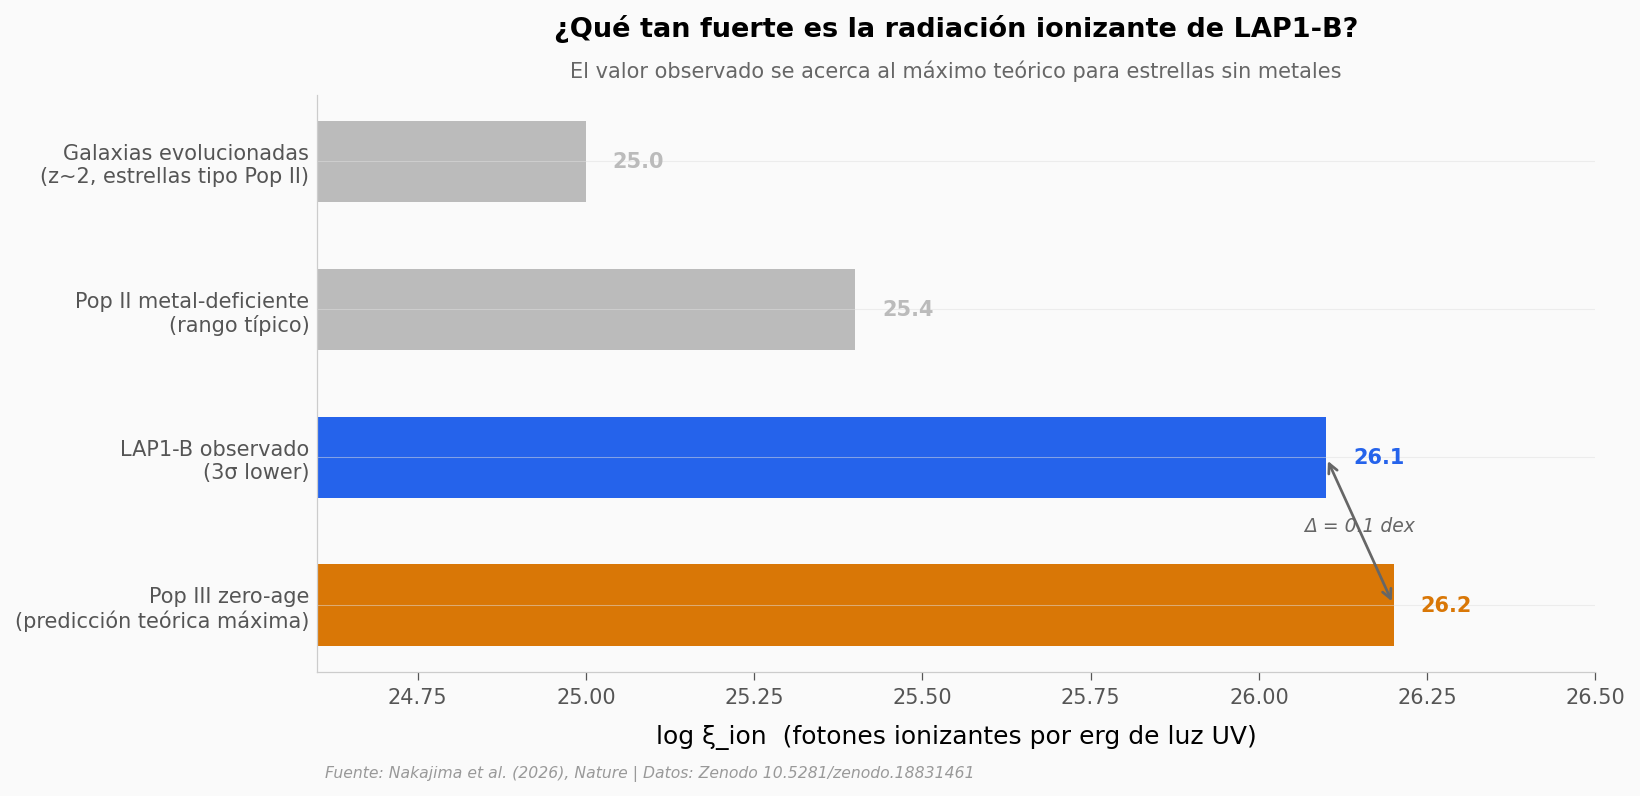

log ξ_ion observado (3σ lower): 26.1
log ξ_ion Pop III zero-age (teórico): 26.2
Distancia: solo 0.1 dex — el límite inferior 3σ ya roza la predicción Pop III.


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

# Eficiencia ionizante observada (3σ lower) vs predicción Pop III
xi_obs_min = 26.1
xi_popIII_zeroage = 26.2
xi_popII_normal = 25.4   # rango típico Pop II metal-deficiente
xi_galaxias_evolved = 25.0  # galaxias formadoras de estrellas a z~2

categorias = {
    'Galaxias evolucionadas\n(z~2, estrellas tipo Pop II)': xi_galaxias_evolved,
    'Pop II metal-deficiente\n(rango típico)': xi_popII_normal,
    'LAP1-B observado\n(3σ lower)': xi_obs_min,
    'Pop III zero-age\n(predicción teórica máxima)': xi_popIII_zeroage,
}

labels = list(categorias.keys())
valores = list(categorias.values())
colores = [COLOR_CONTEXTO, COLOR_CONTEXTO, COLOR_DATOS, COLOR_REFERENCIA]

bars = ax.barh(range(len(labels)), valores, color=colores, height=0.55)
ax.set_xlim(24.6, 26.5)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('log ξ_ion  (fotones ionizantes por erg de luz UV)')
ax.invert_yaxis()
ax.set_title('¿Qué tan fuerte es la radiación ionizante de LAP1-B?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'El valor observado se acerca al máximo teórico para estrellas sin metales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

for i, v in enumerate(valores):
    ax.text(v + 0.04, i, f'{v:.1f}', va='center', fontsize=10,
            fontweight='bold', color=colores[i])

# Flecha mostrando la distancia entre LAP1-B y Pop III zero-age
ax.annotate('', xy=(xi_popIII_zeroage, 3), xytext=(xi_obs_min, 2),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.3))
ax.text((xi_obs_min + xi_popIII_zeroage) / 2, 2.5,
        f'Δ = {xi_popIII_zeroage - xi_obs_min:.1f} dex',
        fontsize=9, color='#666666', ha='center', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/xi_ion_pop3_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'log ξ_ion observado (3σ lower): {xi_obs_min}')
print(f'log ξ_ion Pop III zero-age (teórico): {xi_popIII_zeroage}')
print(f'Distancia: solo {xi_popIII_zeroage - xi_obs_min:.1f} dex — el límite inferior 3σ ya roza la predicción Pop III.')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Redshift z = 6,625 (galaxia a 800 Myr del Big Bang) | ✅ | Calculado desde λ_obs(Hα) = 5,0052 μm: z = 6,626. Diferencia con el paper: 0,0014 — apenas fuera de la barra ±0,001 reportada (atribuible a la precisión del pico en el CSV) |
| Hay cuatro líneas detectadas con S/N ≥ 3 (Hα, Lyα, [O III] 5007, Hβ) | ✅ | Verificado en `lap1b_emission_lines.csv` — el resto de transiciones cae bajo ruido |
| (O/H) = (4,2 ± 1,8) × 10⁻³ × solar (la más químicamente primitiva conocida) | ⚠️ | El valor es del paper; nosotros no recalculamos abundancias (requiere el flujo completo de [O III] auroral y modelos de fotoionización). El paper lo enmarca como afirmación directa (`exhibits`) |
| Sin amplificación por lente (μ = 98) no la veríamos | ⚠️ | El factor de magnificación viene del modelo de lente publicado; lo tomamos como dato, no lo derivamos |
| Masa estelar < 3.300 M☉ (menor que un cúmulo globular típico) | ⚠️ | Es un **límite superior 3σ**, no medición — el continuo estelar no se detecta |
| log ξ_ion observado se acerca al máximo teórico de Pop III | ⚠️ | El valor de LAP1-B es un límite inferior 3σ; la predicción Pop III es teórica. Compatible — no prueba que sea Pop III |
| La población estelar es Pop III pura | ❌ | El paper NO afirma esto. HeII/Hβ < 2,5 (3σ) no distingue entre Pop III y Pop II extremadamente pobre en metales |

> **Limitaciones:** una sola galaxia (no se puede generalizar a la población de enanas ultra-débiles en reionización); la magnificación de la lente se asume uniforme (si varía por región, la M_stellar cambiaría); el flujo de Lyα puede estar parcialmente atenuado por el medio circumgaláctico, así que el EW(Lyα) intrínseco probablemente es mayor que el observado.

## Ahora tú

Tres preguntas para explorar con los CSV cargados:

1. **¿Qué pasa si bajas el umbral de detección a S/N = 2?**
   Pista: cambia `SNR_DETECCION` en la celda de configuración y vuelve a correr la gráfica del espectro. ¿Aparecen líneas razonables o solo ruido?

2. **¿Cómo cambia el redshift recuperado si lo calculamos con Hβ en vez de Hα?**
   Pista: en la celda de zoom, sustituye `Halpha` por `Hbeta` en el filtro de `lines` y recalcula `z`. ¿Las dos líneas dan el mismo redshift?

3. **¿Qué tan extrema es la velocidad de dispersión de gas (58 km/s) para una galaxia de < 3.300 M☉?**
   Pista: usa la relación virial aproximada M_dyn ~ σ² × R / G. Con un radio de 100 pc, calcula la masa dinámica y compárala con la masa estelar máxima. ¿La diferencia es la "huella" de materia oscura?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿Recuperamos el mismo redshift con Hβ?

linea_test = 'Hbeta'   # Cámbiala por 'Lyalpha' u 'OIII_5007' para probar otras

row = lines[lines.linea_codigo == linea_test].iloc[0]
z_test = (row.lam_obs_medido_um / row.lam_rest_um) - 1
print(f'Línea: {row.linea_nombre}')
print(f'  λ_rest  = {row.lam_rest_um} μm')
print(f'  λ_obs   = {row.lam_obs_medido_um} μm')
print(f'  z       = {z_test:.4f}')
print(f'  z paper = {Z_PAPER}')
print(f'  Δz/z    = {abs(z_test - Z_PAPER)/Z_PAPER * 100:.2f}%')

# Pregunta 3: masa dinámica aproximada (relación virial)
import math
sigma_kms = 58
R_pc = 100              # radio asumido
G = 4.302e-3            # pc · M_sun^-1 · (km/s)^2
M_dyn = sigma_kms**2 * R_pc / G
print(f'\nMasa dinámica estimada (σ²·R/G, R = {R_pc} pc):')
print(f'  M_dyn  ≈ {M_dyn:.2e} M☉')
print(f'  M_stellar (3σ upper) = {M_STELLAR_UPPER} M☉')
print(f'  Ratio dinámica/estelar máxima ≈ {M_dyn/M_STELLAR_UPPER:.0f}×')
print('  → Una diferencia tan grande apunta a un halo dominado por materia oscura — es lo que el paper interpreta.')

Línea: Hβ
  λ_rest  = 0.4861 μm
  λ_obs   = 3.7085 μm
  z       = 6.6291
  z paper = 6.625
  Δz/z    = 0.06%

Masa dinámica estimada (σ²·R/G, R = 100 pc):
  M_dyn  ≈ 7.82e+07 M☉
  M_stellar (3σ upper) = 3300 M☉
  Ratio dinámica/estelar máxima ≈ 23696×
  → Una diferencia tan grande apunta a un halo dominado por materia oscura — es lo que el paper interpreta.


## Créditos

**Paper:** Nakajima, K. et al. (2026). *An ultra-faint, chemically primitive galaxy forming in the reionization era.* Nature. [DOI: 10.1038/s41586-026-10374-1](https://doi.org/10.1038/s41586-026-10374-1)

**Datos:** Espectro 1D NIRSpec/PRISM disponible públicamente en [Zenodo](https://doi.org/10.5281/zenodo.18831461). Licencia CC-BY-4.0.

**Repo del Lab:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [An ultra-faint, chemically primitive galaxy forming in the reionization era](https://doi.org/10.1038/s41586-026-10374-1)  
*Nature, 2026-05-13*

**Supplementary Material**: [Supplementary Information — An ultra-faint, chemically primitive galaxy forming in the reionization era](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10374-1/MediaObjects/41586_2026_10374_MOESM1_ESM.pdf)  
*Mismo DOI que el paper — peer-reviewed editorial supplement*

**Dataset canónico**: [Reduced JWST/NIRSpec Spectrum for 'An Ultra-Faint, Chemically Primitive Galaxy Forming in the Reionization Era'](https://doi.org/10.5281/zenodo.18831461)  
*Zenodo, 2026-03-02 — datos reducidos del programa JWST GO-4750*

*15 afirmaciones verificadas contra estas fuentes*